# A single scattering wavefunction

This notebook introduces the complete workflow on one $s$ wave:

1. generate independent FOM snapshots with the regular-origin shooting convention;
2. learn a centered reduced basis and implicit coordinate equation;
3. compare least-squares projection (the basis limit) with the online LROM.

`LROM_FULL_RUN=1` increases the mesh and sample counts. The accelerator
setting is shared with the later notebooks, although this small scalar
problem is normally faster on the CPU.

In [1]:
import os, sys
from pathlib import Path
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".matplotlib-cache"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lrom import BasisConfig, InputSpace, MaxVol, ScatteringLROM, ScatteringProblem, get_runtime
from lrom.diagnostics import relative_l2

plt.style.use("seaborn-v0_8-whitegrid")
FAST = os.getenv("LROM_FULL_RUN", "0") != "1"
BACKEND = os.getenv("LROM_BACKEND", "cpu")       # cpu, gpu, or auto
PRECISION = os.getenv("LROM_PRECISION", "double") # double or single (GPU)
runtime = get_runtime(BACKEND, PRECISION)
print(f"mode={'quick' if FAST else 'full'}, runtime={runtime.name}, device={runtime.device}")

mode=quick, runtime=numpy-cpu, device=CPU


In [2]:
problem = ScatteringProblem(
    potential="real_woods_saxon", target_a=40, target_z=20,
    lab_energy=14.1, l_max=0, mesh_points=400 if FAST else 800,
    target_binding_energy=342.052184,
)
center = problem.reference_omega

def sample(vv):
    row = problem.reference_sample.copy()
    row["Vv"] = float(vv)
    return row

n_train = 21 if FAST else 41
train_vv = np.linspace(.90 * center[0], 1.10 * center[0], n_train)
test_vv = np.linspace(.82 * center[0], 1.18 * center[0], 51)
train_samples = [sample(value) for value in train_vv]
test_samples = [sample(value) for value in test_vv]
training = problem.generate_training_data(train_samples)
testing = problem.generate_training_data(test_samples)

In [3]:
emulator = ScatteringLROM(
    problem, BasisConfig(size=4), MaxVol(count=1, ridge=1e-14)
).train(training)
channel = (0, 0.0)
learned = emulator.channel_models[channel].learned

exact = testing.wavefunctions[channel]
predicted = np.asarray([
    emulator.predict(row).wavefunction(channel) for row in test_samples
])
projected_coordinates = learned.basis.project(exact)
projected = learned.basis.reconstruct(projected_coordinates)

table = pd.DataFrame({
    "method": ["basis projection", "online LROM"],
    "median relative L2": [
        np.median(relative_l2(projected, exact)),
        np.median(relative_l2(predicted, exact)),
    ],
    "maximum relative L2": [
        np.max(relative_l2(projected, exact)),
        np.max(relative_l2(predicted, exact)),
    ],
})
table

,method,median relative L2,maximum relative L2
0,basis projection,4.017162e-08,0.000009
1,online LROM,4.110142e-08,0.000009


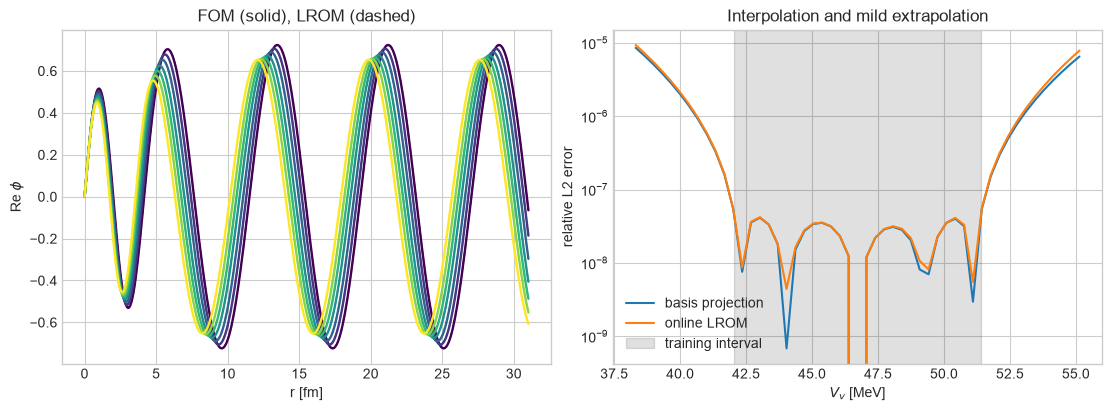

In [4]:
radius = problem.system().radius
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
for index in np.linspace(0, len(test_vv)-1, 7, dtype=int):
    color = plt.cm.viridis(index / (len(test_vv)-1))
    axes[0].plot(radius, exact[index].real, color=color, lw=1.7)
    axes[0].plot(radius, predicted[index].real, color=color, ls="--", lw=1)
axes[0].set(xlabel="r [fm]", ylabel=r"Re $\phi$", title="FOM (solid), LROM (dashed)")
axes[1].semilogy(test_vv, relative_l2(projected, exact), label="basis projection")
axes[1].semilogy(test_vv, relative_l2(predicted, exact), label="online LROM")
axes[1].axvspan(train_vv.min(), train_vv.max(), alpha=.12, color="black", label="training interval")
axes[1].set(xlabel=r"$V_v$ [MeV]", ylabel="relative L2 error", title="Interpolation and mild extrapolation")
axes[1].legend()
plt.show()

The online error contains both basis truncation and learned-coordinate
error. The ridge value is dimensionless: $\alpha=10^{-14}\sigma_{\max}(D)^2$.
Set it to zero in `MaxVol` for ordinary least squares.